# How to use TraceSimulator

This is a short introduction on how to use TraceSimulator to simulate traces for DELight. Before running, remember to install the `TraceSimulator` package doing in the directory containing `setup.py`:

```
pip install -e .
```

### Create a TraceSimulator object

A TraceSimulator object is created by loading a configuration file in yaml format (similar to json, but it allows for comments in the file itself). This part might take up to a minute or more, because most of the input files are compressed numpy files and they require a relatively long time to be decompressed.

In [1]:
import yaml
from TraceSimulator import TraceSimulator

def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('config.yaml')
ts = TraceSimulator(config)

/home/ws/ks0116/software/TraceSimulator/TraceSimulator/TraceSimulator.py:169: RuntimeWarning: overflow encountered in exp
  self.template = np.concatenate([(np.exp((xs - self.trigger_time) / self.tau_rise))[xs <= self.trigger_time], (np.exp(-(xs - self.trigger_time) / self.tau_decay))[xs > self.trigger_time]])


The TraceSimulator object containes SimulationMap objects, each corresponding of a list of PolygonBinning objects, which are the property maps for each MMC. The SimulationMap objects are: `pce` (total PCE), `pce_per_MMC` (PCE per MMC), `tce` (total TCE), `tce_per_MMC` (TCE per MMC), `lce` (total LCE), `lce_per_MMC` (LCE per MMC), `optArrTime` (arrival time of UV photons), `phonArrTime` (arrival time of photons, these are arrays of length 101 with equally spaced percentiles of the phonon template) and `trArrTime` (arrival time of triplets., similar to phonon case). For example, it is possible to see what's the LCE per MMC at a given position in the following way.

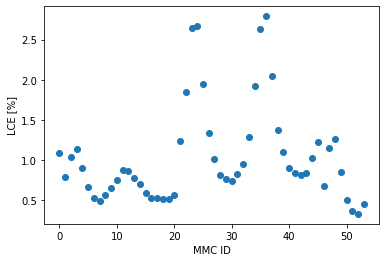

In [2]:
import numpy as np
import matplotlib.pyplot as plt

LCE_MMC = np.array([ts.lce_per_mmc(10., 50., -1800, i)[0] for i in range(ts.n_MMC)])
plt.scatter(np.arange(ts.n_MMC), LCE_MMC * 100)

plt.xlabel('MMC ID'), plt.ylabel('LCE [%]');

It is also possible to visualize the different maps for different slices of z.

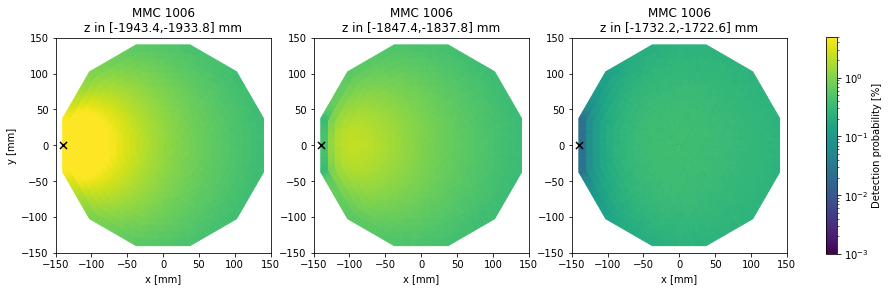

In [3]:
bins_z = np.linspace(*ts.lce.pb.z_lim, ts.lce.pb.Nz + 1)
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

for iz, z in enumerate([1, 11, 23]):
    plt.sca(axs[iz])
    im, ax = ts.lce_per_mmc.pb[15].plot_distribution(z, ax=axs[iz], normalize_area=False,
                                                     cmap='viridis', vmin=1e-3, vmax=5., 
                                                     scale=100., log_scale=True)
    plt.scatter(*ts.MMC_position[15][:2], c='xkcd:black', marker='x', s=50, zorder=10)

    plt.xlim(-150, 150), plt.xlabel('x [mm]')
    plt.ylim(-150, 150)
    if (iz == 0): 
        plt.ylabel('y [mm]')
    plt.title(f"MMC {ts.lce.get_MMC_ID(15)}\nz in [{bins_z[z]:.1f},{bins_z[z+1]:.1f}] mm")
    axs[iz].set_aspect(1.)

fig.colorbar(im, ax=axs, fraction=0.014, label='Detection probability [%]')
plt.show();

## Simulate traces

The minimal working example to simulate traces is given below: when the position of the event is not specified, a random position within the volume will be sampled, while if the interaction type is not specified, an ER is assumed.

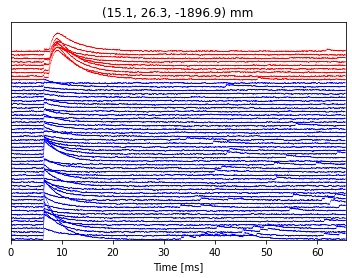

In [4]:
trace, (x, y, z) = ts.generate(2e4, type_recoil='NR') # generate a 20 keV ER from a random position in the volume
times = 0.5 * (ts.t_edges[1:] + ts.t_edges[:-1])
for i in range(54):
    if i > 44:
        plt.plot(times * 1e-6, trace[0][i] + i * 50, c='r', lw=0.2)
    else:
        plt.plot(times * 1e-6, trace[0][i] + i * 50, c='b', lw=0.2)
        
plt.xlim(0, np.max(times * 1e-6)), plt.xlabel('Time [ms]')
plt.ylim(-10), plt.yticks([])
plt.title(f'({x[0]:.1f}, {y[0]:.1f}, {z[0]:.1f}) mm');

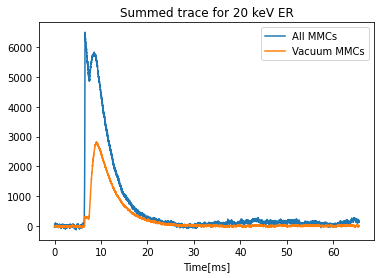

In [5]:
plt.plot(times * 1e-6, np.sum(trace[:,:], axis=1)[0], label='All MMCs')
plt.plot(times * 1e-6, np.sum(trace[:,-9:], axis=1)[0], label='Vacuum MMCs')
plt.legend(), plt.xlabel('Time[ms]'), plt.title('Summed trace for 20 keV ER');